In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_community.chat_models import ChatOpenAI

In [61]:
chat_llm=ChatOpenAI(model="gpt-4.1")

In [62]:
chat_llm.invoke("hey").content

'Hey! How can I help you today? 😊'

In [63]:
os.environ['OPENAI_API_KEY']=OPEANIAI_API_KEY=os.getenv('OPENAI_API_KEY')

In [64]:
from typing_extensions import TypedDict,Annotated,List,Sequence
from langchain_core.messages import AnyMessage,HumanMessage,AIMessage,BaseMessage
import operator

In [65]:
class GraphState(TypedDict):
    messages:Annotated[Sequence[AnyMessage],operator.add]

In [66]:
{
    "messages": [HumanMessage(content="Hi, this is KA. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is KA. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [67]:
def llm_call(state:GraphState)->dict:
    """call llm using conversation message and append on ai system."""
    response=chat_llm.invoke(state['messages'])
    return {
        "messages":[response]
    }

In [68]:
def token_number(state:GraphState)->dict:
    """count tokens of the last ai message."""
    last_message=state['messages'][-1]
    text=last_message.content
    token_number=len(text.split())
    summary=f"total number of tokens to generate answer {token_number}"
    return {
        "messages":[AIMessage(content=summary)]
    }

In [69]:
from langgraph.graph import START,END,StateGraph

In [70]:
graph=StateGraph(GraphState)
graph.add_node("llm_call", llm_call)
graph.add_node("token_counter", token_number)

In [71]:
graph.add_edge(START,"llm_call")
graph.add_edge("llm_call","token_counter")
graph.add_edge("token_counter",END)

In [72]:
graph=graph.compile()

In [73]:
from IPython.display import Image, display

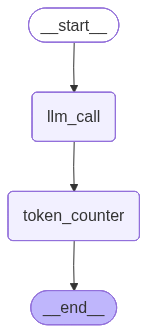

In [74]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
result = graph.invoke({
    "messages": [HumanMessage(content="Hi, this is KA. Say hello in detail.")]
})

In [76]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is KA. Say hello in detail.
AIMessage : Hello, KA! It’s wonderful to meet you. I hope you’re having a fantastic day. If there’s anything you’d like to talk about, ask, or explore together, please let me know—I’m here to help with any questions or conversations you have in mind. How can I assist you today?
AIMessage : total number of tokens to generate answer 48


In [77]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [78]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500)

In [79]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [80]:
wiki_tool.run({"query":"clint eastwood"})

c:\Users\kumar\Desktop\anaco\envs\agentic\Lib\site-packages\wikipedia\wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file c:\Users\kumar\Desktop\anaco\envs\agentic\Lib\site-packages\wikipedia\wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


'Page: Clint Eastwood\nSummary: Clinton Eastwood Jr. (born May 31, 1930) is an American actor, musician, and filmmaker. After achieving success in the Western TV series Rawhide, Eastwood rose to international fame with his role as the "Man with No Name" in Sergio Leone\'s Dollars Trilogy of spaghetti Westerns during the mid-1960s and as antihero cop Harry Callahan in the five Dirty Harry films throughout the 1970s and 1980s. These roles, among others, have made Eastwood an enduring cultural icon of'

In [81]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [82]:
os.environ['TAVILY_API_KEY']=os.getenv('TAVILY_API_KEY')

In [83]:
tool=TavilySearchResults()
tool.run({"query":"clint eastwood"})

'SSLError(MaxRetryError(\'HTTPSConnectionPool(host=\\\'api.tavily.com\\\', port=443): Max retries exceeded with url: /search (Caused by SSLError(SSLCertVerificationError(1, "[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for \\\'api.tavily.com\\\'. (_ssl.c:1032)")))\'))'

In [84]:
from langchain_community.tools import DuckDuckGoSearchRun

In [85]:
search=DuckDuckGoSearchRun()

In [86]:
search.invoke("recently released mobile phone from nokia")

'List of all Nokia phones including latest, upcoming mobile phones from Nokia smartphone brands. Also find Nokia 5g smartphones, camera phones & best Nokia mobiles with price, specifications and reviews. Jun 4, 2025 · As we move through 2025, Nokia ’ s current lineup offers compelling options for durability enthusiasts, budget-conscious 5G adopters, and fans of retro tech. With HMD gradually transitioning to its own brand, this may be one of the last fully Nokia -branded generations of smartphones. Official Nokia smartphones & tablets from HMD Global. From classic models to more recent Android devices, 5G models, budget to premium. Browse over 40 models. Nokia news 110 Power 150 Music 130 Music 110 4G 2nd Edition 105 4G 2nd Edition 108 4G (2024) 110 4G (2024) 105 (2024) 220 4G (2024) 3210 235 4G (2024) 225 4G (2024) 215 4G (2024) 6310 (2024) 5310... Aug 28, 2025 · Nokia ’ s 2025 smartphone lineup has sparked interest with a mix of leaks, rumors, and confirmed launches. HMD, which manag

In [87]:
from langchain_community.tools import YouTubeSearchTool
tool=YouTubeSearchTool()

In [88]:
tool.run("WWE")

"['https://www.youtube.com/watch?v=i1tE3FlOXBU&pp=ygUDV1dF', 'https://www.youtube.com/watch?v=BL-TL-5tMTM&pp=ygUDV1dF']"

In [89]:
from langchain.tools import tool

In [90]:
@tool
def multiply(a:int,b:int)->int:
    """multiplies two numbers"""
    return a*b

In [91]:
multiply.invoke({"a":20,"b":10})

200

In [92]:
multiply.description

'multiplies two numbers'

In [93]:
import yfinance as yf

In [94]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [95]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $264.18.'

In [96]:
tools = [get_stock_price,multiply,wiki_tool]

In [100]:
from langchain_openai import ChatOpenAI
chat_llm = ChatOpenAI(model="gpt-4.1", temperature=0)

In [101]:
llm_with_tools=chat_llm.bind_tools(tools)

In [102]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [103]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [104]:
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [105]:
function_2 = ToolNode(tools)

In [106]:
workflow = StateGraph(MessagesState)

In [107]:
workflow.add_node("llm", function_1)
workflow.add_node("tools", function_2)
workflow.add_edge(START, "llm")
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)
workflow.add_edge("tools", "llm")

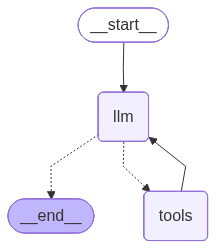

In [108]:
app = workflow.compile()
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [109]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_nXshnaVc9QSFxkzYcI8CZfeN)
 Call ID: call_nXshnaVc9QSFxkzYcI8CZfeN
  Args:
    query: 2026 Indian Union Budget
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai M